# B. Products & Categories

Things done in this category:
1. Loading `products_dataset.csv`, `product_category_name_translation.csv`, `order_items_dataset.csv`
2. Cleaning and building two shared output files: `order_products_summary.csv` and `category_lookup.csv`
3. Exploring category level volume, price, and freight patterns
4. Flagging data quality issues found along the way
5. Detailed analysis of physical attributes, growth and category wise risk

In [2]:
import pandas as pd
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', None)

## 1. Load raw data

In [3]:
products = pd.read_csv('products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
items = pd.read_csv('order_items_dataset.csv')

print("products shape:", products.shape)
print("translation shape:", translation.shape)
print("order_items shape:", items.shape)

products shape: (32951, 9)
translation shape: (71, 2)
order_items shape: (112650, 7)


In [4]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [5]:
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [6]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## 2. Initial data quality checks

In [7]:
print("Nulls in products:")
print(products.isnull().sum())

print("\nRows missing category (and related metadata together):", products['product_category_name'].isnull().sum())

Nulls in products:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Rows missing category (and related metadata together): 610


In [8]:
print("Nulls in order_items:")
print(items.isnull().sum())

Nulls in order_items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [9]:
print("price distributions")
print(items['price'].describe())

price distributions
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64


In [10]:
print("freight distributions")
print(items['freight_value'].describe())

print("\nRows with freight_value == 0:", (items['freight_value'] == 0).sum())

freight distributions
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

Rows with freight_value == 0: 383


In [12]:
cats_in_products = set(products['product_category_name'].dropna().unique())
cats_in_translation = set(translation['product_category_name'].unique())

missing_translation = cats_in_products - cats_in_translation
print("Categories in products but missing from translation table:", missing_translation)


Categories in products but missing from translation table: {'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}


In [13]:
# The number of orders with these missing categories in translation
for cat in ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']:
    n_products = (products['product_category_name'] == cat).sum()
    prod_ids = products.loc[products['product_category_name'] == cat, 'product_id']
    n_items = items['product_id'].isin(prod_ids).sum()
    print(f"{cat} has: {n_products} products and {n_items} order rows")

pc_gamer has: 3 products and 9 order rows
portateis_cozinha_e_preparadores_de_alimentos has: 10 products and 15 order rows


**Finding:** 2 categories (`pc_gamer`, `portateis_cozinha_e_preparadores_de_alimentos`) that exist in
`products` but have no row in the official translation table.

- But there are only 9 and 15 `order_items` rows respectively (24 total) which is small enough to translate manually rather than drop.

In [14]:
# Does every order_item's product_id exist in products, and vice versa?
print("order_items rows with product_id NOT in products:", (~items['product_id'].isin(products['product_id'])).sum())
print("products never appearing in any order:", (~products['product_id'].isin(items['product_id'])).sum())

order_items rows with product_id NOT in products: 0
products never appearing in any order: 0


## 3. Build `order_products_summary.csv` and `category_lookup.csv`

**Category translation:** patch the 2 missing categories manually, and explicitly label the 610 products with no category at all as `unknown` (kept visible, not dropped).

**Primary category per order:** an order can contain items from multiple categories. We are taking the category of the highest priced item in the order as its primary category which is a reasonable approximation for what this order is mainly about.

In [15]:
manual_translation = pd.DataFrame({
    'product_category_name': ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'],
    'product_category_name_english': ['pc_gamer', 'kitchen_appliances']
})
translation_full = pd.concat([translation, manual_translation], ignore_index=True)

products = products.merge(translation_full, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

print("Unmapped categories remaining:", products['product_category_name_english'].isnull().sum())
print("Products labeled 'unknown':", (products['product_category_name_english'] == 'unknown').sum())

Unmapped categories remaining: 0
Products labeled 'unknown': 610


In [16]:
items_cat = items.merge(
    products[['product_id', 'product_category_name_english', 'product_weight_g']],
    on='product_id', how='left'
)

def primary_category(g):
    return g.loc[g['price'].idxmax(), 'product_category_name_english']

order_products_summary = items_cat.groupby('order_id').apply(
    lambda g: pd.Series({
        'primary_category': primary_category(g),
        'n_items': len(g),
        'n_distinct_categories': g['product_category_name_english'].nunique(),
        'total_price': g['price'].sum(),
        'total_freight': g['freight_value'].sum()
    }), include_groups=False
).reset_index()

print("Shape:", order_products_summary.shape)
order_products_summary.head()

Shape: (98666, 6)


,order_id,primary_category,n_items,n_distinct_categories,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,perfumery,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,1,1,199.90,18.14


In [17]:
order_products_summary.to_csv('order_products_summary.csv', index=False)
print("Saved order_products_summary.csv:", order_products_summary.shape)

Saved order_products_summary.csv: (98666, 6)


In [18]:
category_lookup = items_cat.groupby('product_category_name_english').agg(
    n_items_sold=('order_id', 'count'),
    n_orders=('order_id', 'nunique'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_freight=('freight_value', 'mean')
).reset_index().sort_values('n_items_sold', ascending=False)

category_lookup.to_csv('category_lookup.csv', index=False)
print("Saved category_lookup.csv:", category_lookup.shape)
category_lookup.head(15)

Saved category_lookup.csv: (74, 6)


,product_category_name_english,n_items_sold,n_orders,avg_price,median_price,avg_freight
7,bed_bath_table,11115,9417,93.296327,79.05,18.415928
43,health_beauty,9670,8836,130.163531,79.90,18.879703
67,sports_leisure,8641,7720,114.344285,78.00,19.512500
39,furniture_decor,8334,6449,87.564494,65.49,20.728258
15,computers_accessories,7827,6689,116.513903,81.99,18.821781
49,housewares,6964,5884,90.788148,59.80,20.986374
73,watches_gifts,5991,5624,201.135984,129.00,16.781160
70,telephony,4545,4199,71.213978,29.99,15.669041
42,garden_tools,4347,3518,111.630196,59.90,22.765758
5,auto,4235,3897,139.957523,84.90,21.880569


## 4. Sanity check: orders with no items at all
Total orders in `orders_master.csv` should be >= orders in `order_products_summary.csv` and some
orders (unavailable/canceled before item assignment) never get a line item.

In [20]:
orders_master = pd.read_csv('orders_master.csv')
no_items = orders_master[~orders_master['order_id'].isin(order_products_summary['order_id'])]
print("Orders with no items at all:", len(no_items))
print()
print(no_items['order_status'].value_counts())

Orders with no items at all: 775

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


**Finding:** the 775 orders with no items are dominated by `unavailable` (603) and `canceled` (164), orders that never got a product line item attached, are consistent with those statuses.There are some small residual counts (`created`, `invoiced`, `shipped`) not worth chasing further.

## 5. Exploratory analysis of category patterns

In [21]:
print("Total distinct categories:", category_lookup.shape[0])
category_lookup.head(15)

Total distinct categories: 74


,product_category_name_english,n_items_sold,n_orders,avg_price,median_price,avg_freight
7,bed_bath_table,11115,9417,93.296327,79.05,18.415928
43,health_beauty,9670,8836,130.163531,79.90,18.879703
67,sports_leisure,8641,7720,114.344285,78.00,19.512500
39,furniture_decor,8334,6449,87.564494,65.49,20.728258
15,computers_accessories,7827,6689,116.513903,81.99,18.821781
49,housewares,6964,5884,90.788148,59.80,20.986374
73,watches_gifts,5991,5624,201.135984,129.00,16.781160
70,telephony,4545,4199,71.213978,29.99,15.669041
42,garden_tools,4347,3518,111.630196,59.90,22.765758
5,auto,4235,3897,139.957523,84.90,21.880569


**Finding:** 74 total categories exist. Although charting
all 74 in one view won't be good so can instead just take a top N (e.g. top 15 to 20 by volume) or use a small multiples grid rather than a single crowded chart.

In [22]:
print("Bottom 10 categories by volume (long tail):")
category_lookup.tail(10)

Bottom 10 categories by volume (long tail):


,product_category_name_english,n_items_sold,n_orders,avg_price,median_price,avg_freight
35,flowers,33,29,33.637576,25.990,14.814242
32,fashion_sport,30,27,70.650333,59.900,19.271000
46,home_comfort_2,30,24,25.342333,12.900,13.677000
3,arts_and_craftmanship,24,23,75.583750,44.900,15.422083
51,kitchen_appliances,15,14,264.568667,34.900,20.650667
11,cds_dvds_musicals,14,12,52.142857,45.000,16.070714
53,la_cuisine,14,13,146.785000,137.000,23.825000
60,pc_gamer,9,8,171.772222,129.990,14.841111
29,fashion_childrens_clothes,8,8,71.231250,69.945,11.938750
63,security_and_services,2,2,141.645000,141.645,20.610000


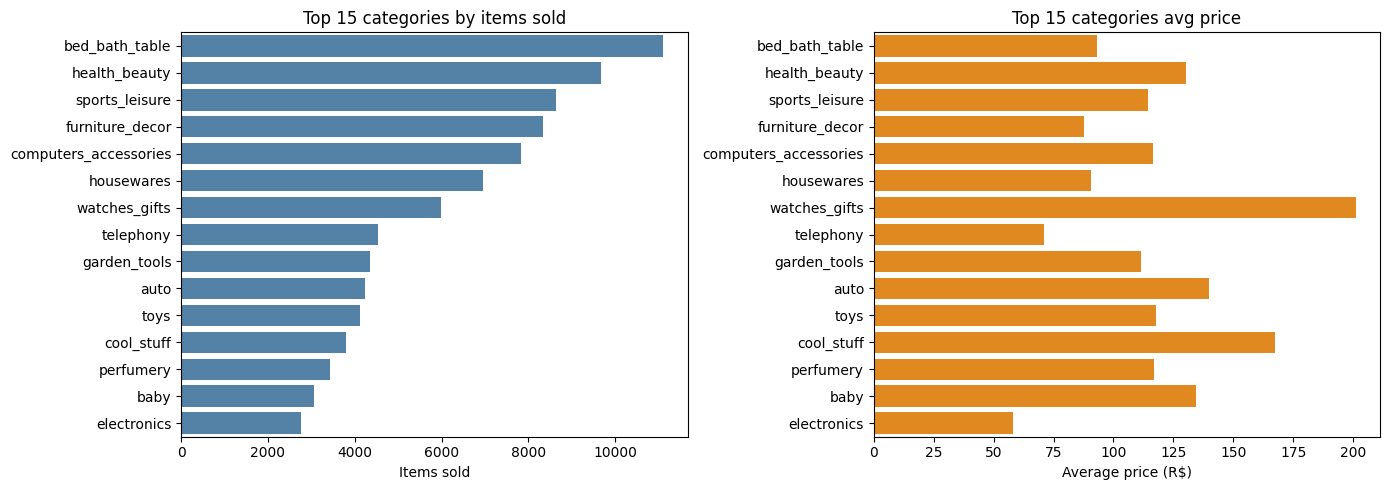

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

top15 = category_lookup.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top15, y='product_category_name_english', x='n_items_sold', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 categories by items sold')
axes[0].set_xlabel('Items sold')
axes[0].set_ylabel('')

sns.barplot(data=top15, y='product_category_name_english', x='avg_price', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 categories avg price')
axes[1].set_xlabel('Average price (R$)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Multi item / multi category orders

In [24]:
print("Orders with more than 1 item:", (order_products_summary['n_items'] > 1).sum(), "/", len(order_products_summary))
print("\nOrders spanning more than 1 distinct category:", (order_products_summary['n_distinct_categories'] > 1).sum())

Orders with more than 1 item: 9803 / 98666

Orders spanning more than 1 distinct category: 786


## 6. Some questions to think about
- Is highest priced item = primary category the right definition, or would most items from that category be more meaningful for some orders?

- Top N vs. small multiples for the eventual category charts, which will fit better?

- The 383 zero freight rows which is worth checking if these cluster in specific categories/sellers (could indicate a promo pattern) or are evenly spread (more likely a genuine no shipping cost case)?


# 7. Deeper Analysis: Physical Attributes, Growth & Category Risk

The sections above establish category volume, price, and freight patterns.

This section checks further using columns that hadn't been used yet (weight, dimensions, photo count) and asks more comparative questions like, which categories are growing or shrinking, which carry disproportionate cancellation or freight risk?

## 7.1 Do physical attributes actually predict freight cost?

Freight cost is set by Olist's logistics pricing, presumably based on weight/size but its worth confirming directly rather than assuming, since it's the kind of relationship a chart could otherwise get wrong by using price instead of physical size as the driver.

In [25]:
items_full = items.merge(products, on='product_id', how='left')
items_full['volume_cm3'] = (
    items_full['product_length_cm'] * items_full['product_height_cm'] * items_full['product_width_cm']
)

print("Correlation, product_weight_g vs freight_value:", round(items_full['product_weight_g'].corr(items_full['freight_value']), 3))
print("Correlation, volume_cm3 vs freight_value:", round(items_full['volume_cm3'].corr(items_full['freight_value']), 3))

Correlation, product_weight_g vs freight_value: 0.61
Correlation, volume_cm3 vs freight_value: 0.587


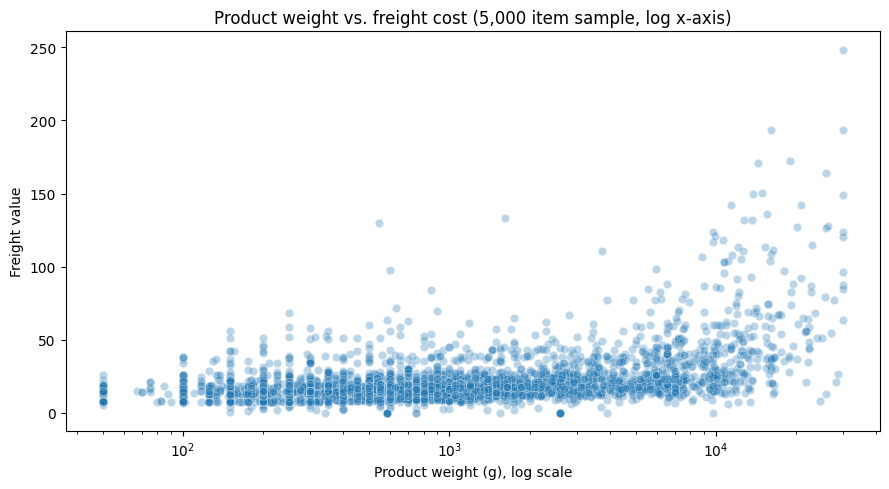

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sample = items_full.dropna(subset=['product_weight_g', 'freight_value']).sample(5000, random_state=42)
sns.scatterplot(data=sample, x='product_weight_g', y='freight_value', alpha=0.3, ax=ax)
ax.set_xscale('log')
ax.set_title('Product weight vs. freight cost (5,000 item sample, log x-axis)')
ax.set_xlabel('Product weight (g), log scale')
ax.set_ylabel('Freight value')
plt.tight_layout()
plt.show()


**Finding:** a real, but moderately positive relationship weight correlates with freight at 0.61, and volume at 0.59.

- Not perfectly linear (freight pricing likely has tiers/minimums), but it confirms freight cost is genuinely driven by physical size, not just an arbitrary or price based charge.

- This is a useful context for the freight ratio by category finding below because a category's freight burden is at least partly explained by what it physically ships, not necessarily a pricing anomaly.

## 7.2 Does listing quality (photo count) relate to price? : checked and ruled out

A possible hypothesis: better photographed listings might command higher prices. Quick check before spending more time on it.

In [27]:
print("Correlation, product_photos_qty vs price:", round(items_full['product_photos_qty'].corr(items_full['price']), 3))

Correlation, product_photos_qty vs price: 0.052


**Finding:** essentially zero (0.05). Photo count doesn't relate to price in this dataset so it is ruled out, and not worth a dedicated chart.

## 7.3 Cancellation rate by category

Section 4 already covers category volume and price. But cancellation is a different, more direct risk signal worth checking on its own as which categories fail to complete an order most often, not just which are large.

In [28]:
order_products_summary = order_products_summary.merge(
    orders_master[['order_id', 'is_canceled', 'purchase_month']], on='order_id', how='left'
)

top15_categories = category_lookup.head(15)['product_category_name_english']
cancel_by_category = (
    order_products_summary[order_products_summary['primary_category'].isin(top15_categories)]
    .groupby('primary_category')['is_canceled']
    .agg(pct_canceled='mean', n_orders='count')
    .sort_values('pct_canceled', ascending=False)
)
cancel_by_category['pct_canceled'] = (cancel_by_category['pct_canceled'] * 100).round(2)
cancel_by_category

,pct_canceled,n_orders
primary_category,,
toys,0.80,3870
housewares,0.64,5821
auto,0.62,3880
sports_leisure,0.61,7683
baby,0.56,2837
computers_accessories,0.52,6670
perfumery,0.45,3145
cool_stuff,0.42,3603
health_beauty,0.40,8801


**Finding:** Again a real but modest spread from 0.19% (bed_bath_table) to 0.80% (toys)
among the top 15 categories by volume, roughly a 4x difference.

- Which is consistent with the dataset wide 0.6% cancellation rate from Category A. So no category is a dramatic outlier, but toys, housewares,
and auto sit consistently above the pack and could be worth a specific look if Catgory D finds these categories also review worse.

## 7.4 Which categories are growing or shrinking?

Category A's monthly growth vs quality finding looked at the marketplace overall. This asks the same growth question one level down. Did every category grow alongside the marketplace, or did some of them fail to continue the trend?

In [30]:
early = order_products_summary[order_products_summary['purchase_month'] < '2018-01']
late = order_products_summary[order_products_summary['purchase_month'] >= '2018-01']

early_months = early['purchase_month'].nunique()
late_months = late['purchase_month'].nunique()

category_growth = pd.DataFrame({
    'early_monthly_rate': early.groupby('primary_category').size() / early_months,
    'late_monthly_rate': late.groupby('primary_category').size() / late_months
}).fillna(0)

category_growth = category_growth[(category_growth['early_monthly_rate'] + category_growth['late_monthly_rate']) > 20]
category_growth['growth_pct'] = (
    (category_growth['late_monthly_rate'] - category_growth['early_monthly_rate'])
    / category_growth['early_monthly_rate'].replace(0, 0.01) * 100
).round(1)

print("Categories that grew slower than the marketplace, or declined (pre 2018 vs 2018+ monthly rate):")
print(category_growth.sort_values('growth_pct').head(10))


Categories that grew slower than the marketplace, or declined (pre 2018 vs 2018+ monthly rate):
                          early_monthly_rate  late_monthly_rate  growth_pct
primary_category                                                           
market_place                       12.133333          10.222222       -15.8
toys                              164.400000         156.000000        -5.1
consoles_games                     44.733333          42.888889        -4.1
home_confort                       15.466667          15.888889         2.7
cool_stuff                        146.800000         155.666667         6.0
unknown                            53.533333          68.000000        27.0
garden_tools                      130.866667         167.333333        27.9
fashion_bags_accessories           68.666667          91.666667        33.5
luggage_accessories                37.333333          51.888889        39.0
perfumery                         111.400000         163.777778     

**Finding:** almost every category grew alongside the marketplace's overall expansion as expected, since total volume grew substantially.

- But three categories with meaningful volume actually declined in monthly rate despite that overall growth: `market_place` (-15.8%), `toys` (-5.1%), and `consoles_games` (-4.1%).

- This is a real finding growth isn't happening everywhere which is worth a chart, distinct from the categories merely growing slower than average.

**Note:** some very high growth percentages in this table come from a
tiny early period base, e.g. 1 order/month and these are not included above since they're not meaningful trends, just small sample artifacts. Although the full table is available if useful, filtered here to the
declining end which is the more interesting, part of the finding.

## 7.5 Freight burden by category

Section 4's freight numbers are absolute. Freight as a proportion of price is more comparable across categories of very different typical value, and more directly answers which categories have a freight problem rather than which categories ship expensive items.

Ties to 7.1 above so we can expect this to correlate with typically bulky/heavy categories.

In [32]:
category_lookup['freight_ratio'] = category_lookup['avg_freight'] / category_lookup['avg_price']

print("Highest freight-to-price ratio categories:\n")
print(category_lookup.sort_values('freight_ratio', ascending=False)[
    ['product_category_name_english', 'avg_price', 'avg_freight', 'freight_ratio']
].head(10).to_string(index=False))

Highest freight-to-price ratio categories:

    product_category_name_english  avg_price  avg_freight  freight_ratio
                   home_comfort_2  25.342333    13.677000       0.539690
                          flowers  33.637576    14.814242       0.440408
furniture_mattress_and_upholstery 114.949474    42.906842       0.373267
               christmas_supplies  57.521699    21.106536       0.366932
              diapers_and_hygiene  40.194615    14.709744       0.365963
                cds_dvds_musicals  52.142857    16.070714       0.308205
           signaling_and_security 108.086583    32.702613       0.302559
                       food_drink  54.602446    16.215791       0.296979
                      electronics  57.913531    16.833509       0.290666
                    fashion_sport  70.650333    19.271000       0.272766


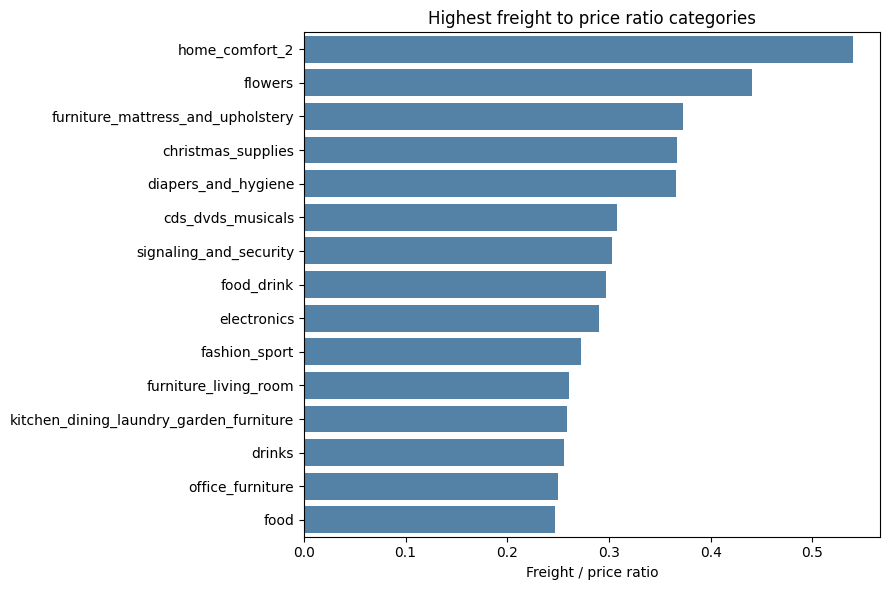

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
top_ratio = category_lookup.sort_values('freight_ratio', ascending=False).head(15)
sns.barplot(data=top_ratio, y='product_category_name_english', x='freight_ratio', color='steelblue', ax=ax)
ax.set_title('Highest freight to price ratio categories')
ax.set_xlabel('Freight / price ratio')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Finding:** `home_comfort_2` and `flowers` lead, with freight running 44 to 54% of item price, meaning shipping cost is a huge fraction of what the customer pays for these
categories.

- `furniture_mattress_and_upholstery` is the highest value category in this list with (avg price of 115 Real) but still carries a 37% freight ratio.

- So this can be a freight risk chart showing categories where the shipping cost itself could plausibly be denting customer satisfaction or conversion, which we can test Category D's review data is available.

## 7.6 Save updated `order_products_summary.csv`

`is_canceled` and `purchase_month` (merged in for 7.3/7.4 above) are useful columns to keep on the file directly, so the other tracks don't need to re join `orders_master.csv` just for these two fields.

In [35]:
order_products_summary.to_csv('order_products_summary.csv', index=False)
print("Re saved order_products_summary.csv with 2 new columns: is_canceled, purchase_month")
print("Shape:", order_products_summary.shape)

Re saved order_products_summary.csv with 2 new columns: is_canceled, purchase_month
Shape: (98666, 8)


In [36]:
order_products_summary.head()

,order_id,primary_category,n_items,n_distinct_categories,total_price,total_freight,is_canceled,purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,1,1,58.90,13.29,False,2017-09
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,1,1,239.90,19.93,False,2017-04
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,1,1,199.00,17.87,False,2018-01
3,00024acbcdf0a6daa1e931b038114c75,perfumery,1,1,12.99,12.79,False,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,1,1,199.90,18.14,False,2017-02


## 7.7 More questions to think about:

- `market_place`, `toys`, and `consoles_games` are declining while the marketplace grows overall which is worth a specific question to discuss as: is this a data artifact (e.g. a changing category taxonomy over time) or a real business signal worth flagging to leadership?

- The freight ratio finding (7.5) and the physical-attributes correlation (7.1) fit together which is worth considering a combined chart or narrative rather than two separate ones covering the same things.

- Toys/housewares/auto's modestly elevated cancellation rate (7.3) which is worth cross checking against Category D's review scores once available.
